# Dataset EDA


## Imports


In [13]:
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import pandas as pd

## Constants


In [14]:
DATASET_PATH = "athens-osmWebWizard/dump-train-athens-10h.xml"

TRAFFIC_GENERATION_PERIODS = [2.07, 1.27, 1.06, 1.05, 0.99, 0.90, 0.92, 0.91, 0.88, 0.93] + [1.0]

## XML Parsing


In [15]:
def parse_netstate(file_path: str) -> pd.DataFrame:
    """
    Parses a SUMO netstate XML file into a pandas DataFrame with columns:
    'timestep_time', 'edge_id', 'lane_id', 'vehicle_id', 'position', 'speed_kmh'.
    """
    records = []
    context = ET.iterparse(file_path, events=("end",))
    for event, elem in context:
        if elem.tag == "timestep":
            time = float(elem.get("time"))
            for edge in elem.findall("edge"):
                edge_id = edge.get("id")
                for lane in edge.findall("lane"):
                    lane_id = lane.get("id")
                    for veh in lane.findall("vehicle"):
                        speed_ms = float(veh.get("speed"))
                        records.append(
                            {
                                "timestep_time": time,
                                "edge_id": edge_id,
                                "lane_id": lane_id,
                                "vehicle_id": veh.get("id"),
                                "position": float(veh.get("pos")),
                                "speed_kmh": speed_ms * 3.6,
                            }
                        )
            elem.clear()
    df = pd.DataFrame(records)
    return df


# Load and clean data
df = parse_netstate(DATASET_PATH)
df = df.dropna().reset_index(drop=True)

## Overview


In [16]:
print("Data shape:", df.shape)
print(df[["timestep_time", "speed_kmh", "position"]].describe())
print("Unique vehicles:", df["vehicle_id"].nunique())
print("Time span: {:.2f} s to {:.2f} s".format(df["timestep_time"].min(), df["timestep_time"].max()))

Data shape: (7069078, 6)
       timestep_time     speed_kmh      position
count   7.069078e+06  7.069078e+06  7.069078e+06
mean    1.991001e+04  2.987405e+01  4.041287e+01
std     9.743844e+03  2.302683e+01  4.689808e+01
min     0.000000e+00  0.000000e+00  0.000000e+00
25%     1.189800e+04  8.856000e+00  9.490000e+00
50%     2.040100e+04  2.854800e+01  2.933000e+01
75%     2.828300e+04  4.561200e+01  5.777750e+01
max     3.634200e+04  1.285200e+02  9.311000e+02
Unique vehicles: 33652
Time span: 0.00 s to 36342.00 s


## Data Engineering


In [17]:
# Add derived columns
df["second"] = df["timestep_time"].astype(int)
df["hour"] = (df["timestep_time"] // 3600).astype(int)

# Aggregations
secondly = (
    df.groupby("second").agg(avg_speed_kmh=("speed_kmh", "mean"), vehicle_count=("vehicle_id", "nunique")).reset_index()
)

hourly = (
    df.groupby("hour").agg(avg_speed_kmh=("speed_kmh", "mean"), vehicle_count=("vehicle_id", "nunique")).reset_index()
)

## Plots


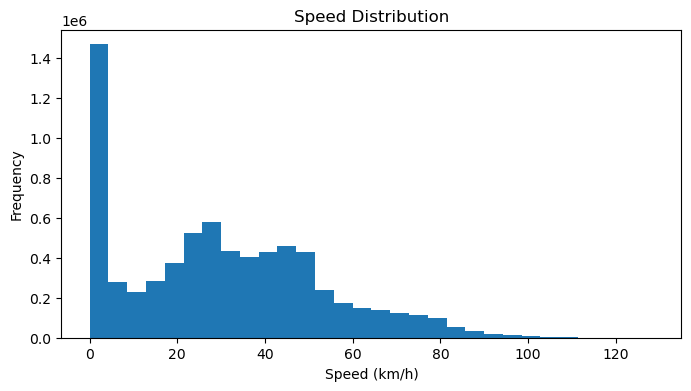

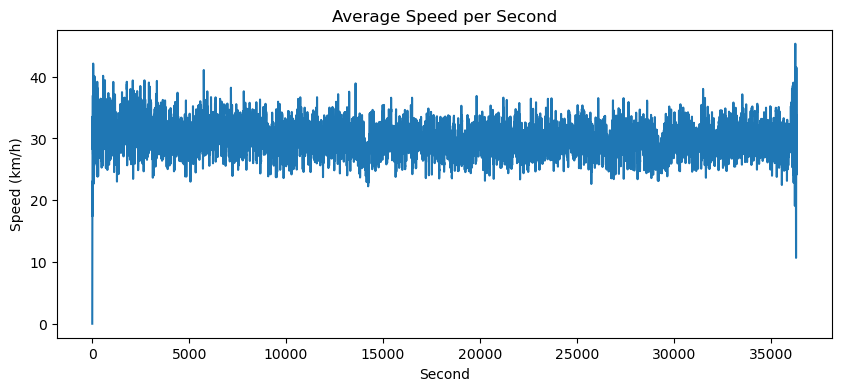

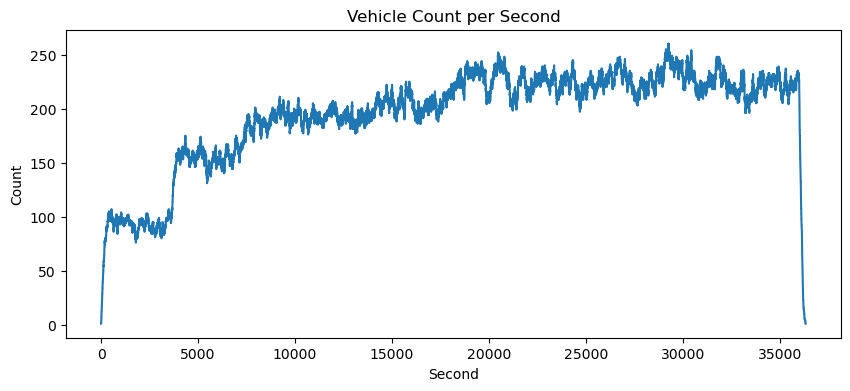

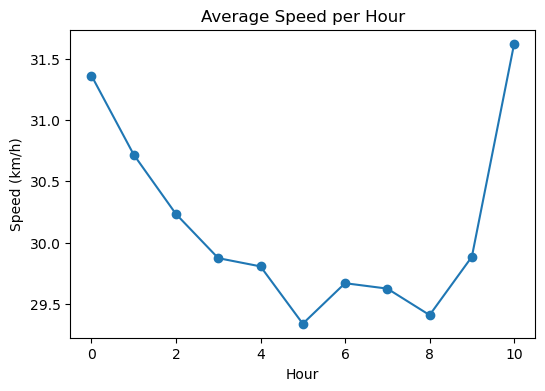

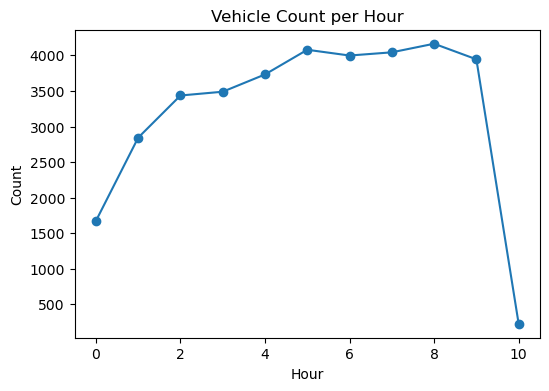

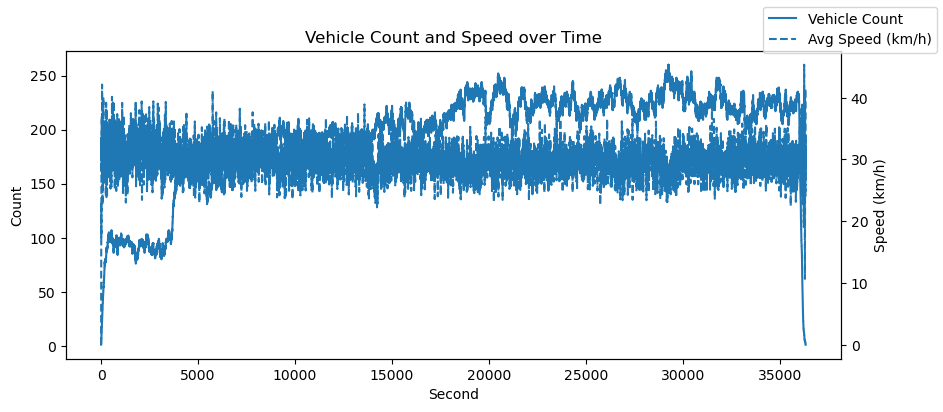

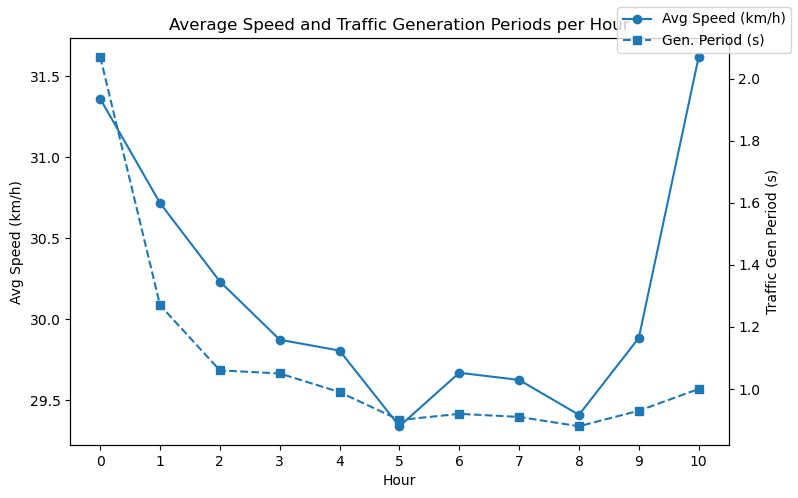

: 

In [ ]:
# 1) Histogram of speeds (km/h)
plt.figure(figsize=(8, 4))
plt.hist(df["speed_kmh"], bins=30)
plt.title("Speed Distribution")
plt.xlabel("Speed (km/h)")
plt.ylabel("Frequency")
plt.show()

# 2) Avg speed per second
plt.figure(figsize=(10, 4))
plt.plot(secondly["second"], secondly["avg_speed_kmh"])
plt.title("Average Speed per Second")
plt.xlabel("Second")
plt.ylabel("Speed (km/h)")
plt.show()

# 3) Vehicle count per second
plt.figure(figsize=(10, 4))
plt.plot(secondly["second"], secondly["vehicle_count"])
plt.title("Vehicle Count per Second")
plt.xlabel("Second")
plt.ylabel("Count")
plt.show()

# 4) Avg speed per hour
plt.figure(figsize=(6, 4))
plt.plot(hourly["hour"], hourly["avg_speed_kmh"], marker="o")
plt.title("Average Speed per Hour")
plt.xlabel("Hour")
plt.ylabel("Speed (km/h)")
plt.show()

# 5) Vehicle count per hour
plt.figure(figsize=(6, 4))
plt.plot(hourly["hour"], hourly["vehicle_count"], marker="o")
plt.title("Vehicle Count per Hour")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()

# 6) Time series overlay: count & speed
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(secondly["second"], secondly["vehicle_count"], label="Vehicle Count")
ax1.set_xlabel("Second")
ax1.set_ylabel("Count")
ax2 = ax1.twinx()
ax2.plot(secondly["second"], secondly["avg_speed_kmh"], label="Avg Speed (km/h)", linestyle="--")
ax2.set_ylabel("Speed (km/h)")
fig.legend(loc="upper right")
plt.title("Vehicle Count and Speed over Time")
plt.show()

# 7) Avg speed per hour with traffic generation periods overlay
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(hourly["hour"], hourly["avg_speed_kmh"], marker="o", label="Avg Speed (km/h)")
ax1.set_xlabel("Hour")
ax1.set_ylabel("Avg Speed (km/h)")
ax1.set_xticks(hourly["hour"])

ax2 = ax1.twinx()
ax2.plot(hourly["hour"], TRAFFIC_GENERATION_PERIODS, marker="s", linestyle="--", label="Gen. Period (s)")
ax2.set_ylabel("Traffic Gen Period (s)")

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
fig.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

plt.title("Average Speed and Traffic Generation Periods per Hour")
plt.tight_layout()
plt.show()